# Stage 6: Data Analysis
Capstone Project: Spam Message Analysis Using Malicious URLs

Correlation analysis, chi-square test (has_ip_address vs type) and a Random Forest classifier with feature importance.

In [1]:
from pathlib import Path

# Project root = parent of this notebook's stage folder (run the notebook from inside its own folder)
ROOT = Path.cwd().parent
RAW_CSV = ROOT / "dataset" / "dataset.csv"
INTER = ROOT / "dataset" / "intermediate"      # output of each stage becomes input of the next
RESULTS = ROOT / "results"
GRAPH_DIR = RESULTS / "graphs"
for p in (INTER, RESULTS, GRAPH_DIR):
    p.mkdir(parents=True, exist_ok=True)


In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

df_final = pd.read_csv(INTER / "stage4_clean.csv", keep_default_na=False)
print("Loaded cleaned data:", df_final.shape)


Loaded cleaned data: (640088, 19)


## Stage 6 — Data Analysis
Statistical relationships between features and class, plus a simple classifier.

In [3]:
numeric_columns = [
    "url_length", "subdomain_count", "path_length", "query_length",
    "has_https", "has_ip_address", "dot_count", "hyphen_count",
    "digit_count", "special_char_count", "has_at_symbol",
    "has_shortener", "keyword_count"
]

corr_matrix = df_final[numeric_columns].corr()
corr_matrix

,url_length,subdomain_count,path_length,query_length,has_https,has_ip_address,dot_count,hyphen_count,digit_count,special_char_count,has_at_symbol,has_shortener,keyword_count
url_length,1.000000,0.243973,0.547394,0.730994,0.072921,-0.074495,0.382222,0.429392,0.682889,0.810770,0.045943,-0.025707,0.280797
subdomain_count,0.243973,1.000000,-0.017312,0.077304,-0.000007,-0.068478,0.709091,-0.053501,0.248016,0.134069,-0.000223,-0.014477,0.342008
path_length,0.547394,-0.017312,1.000000,-0.108111,0.018830,-0.079953,0.039893,0.611342,0.346920,0.492067,0.026989,-0.019903,0.093244
query_length,0.730994,0.077304,-0.108111,1.000000,0.052439,-0.044459,0.264743,0.043774,0.494951,0.578908,0.027938,-0.008730,0.181135
has_https,0.072921,-0.000007,0.018830,0.052439,1.000000,-0.020543,0.011083,-0.005345,0.089671,0.066134,0.103714,0.035069,0.033680
has_ip_address,-0.074495,-0.068478,-0.079953,-0.044459,-0.020543,1.000000,0.149451,-0.069602,0.095451,-0.006852,-0.004842,-0.004075,-0.027771
dot_count,0.382222,0.709091,0.039893,0.264743,0.011083,0.149451,1.000000,-0.080235,0.308134,0.318872,0.039268,-0.022497,0.374091
hyphen_count,0.429392,-0.053501,0.611342,0.043774,-0.005345,-0.069602,-0.080235,1.000000,0.157697,0.437852,0.012906,-0.014908,0.017403
digit_count,0.682889,0.248016,0.346920,0.494951,0.089671,0.095451,0.308134,0.157697,1.000000,0.530716,0.020800,-0.008061,0.228037
special_char_count,0.810770,0.134069,0.492067,0.578908,0.066134,-0.006852,0.318872,0.437852,0.530716,1.000000,0.054825,-0.021839,0.174544


In [4]:
from scipy.stats import chi2_contingency

# Is there a statistically significant relationship between having an IP address
# in the hostname and the URL type?
contingency = pd.crosstab(df_final["has_ip_address"], df_final["type"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(contingency)
print(f"\nChi-square = {chi2:.2f}, p-value = {p_value:.6f}")
if p_value < 0.05:
    print("=> Statistically significant relationship between has_ip_address and type.")
else:
    print("=> No statistically significant relationship found.")

type            benign  defacement  malware  phishing
has_ip_address                                       
0               427355       95150    11862     93615
1                   26           0    11750       330

Chi-square = 302842.09, p-value = 0.000000
=> Statistically significant relationship between has_ip_address and type.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

model_features = numeric_columns  # purely numeric, engineered features
X = df_final[model_features]
y = df_final["type"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8846959021387617

Classification report:

              precision    recall  f1-score   support

      benign       0.88      0.97      0.92     85477
  defacement       0.89      0.80      0.84     19030
     malware       0.99      0.77      0.87      4722
    phishing       0.85      0.62      0.72     18789

    accuracy                           0.88    128018
   macro avg       0.90      0.79      0.84    128018
weighted avg       0.88      0.88      0.88    128018



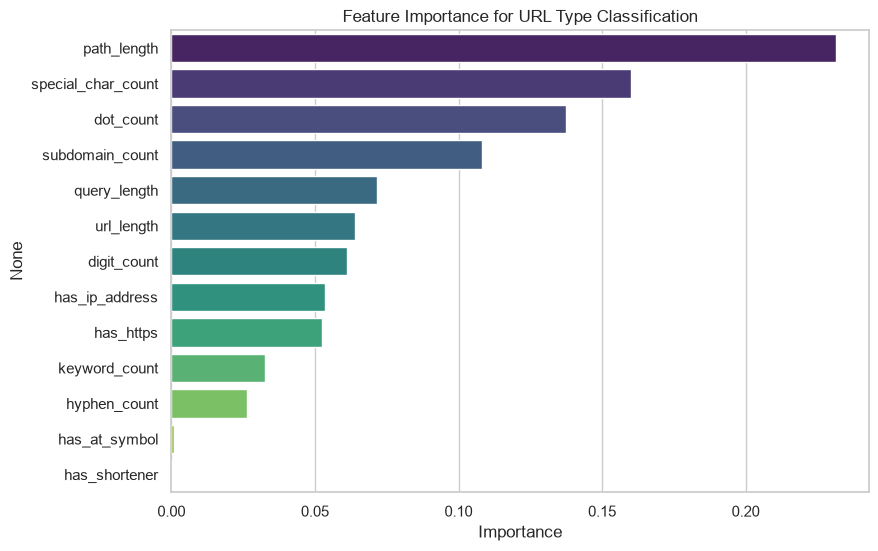

In [8]:
# Feature importance — which engineered features matter most for classifying URL type?
importances = pd.Series(clf.feature_importances_, index=model_features).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Feature Importance for URL Type Classification")
plt.xlabel("Importance")
plt.savefig(GRAPH_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ---- Save model outputs for Stage 7 and Stage 8 ----
report_text = classification_report(y_test, y_pred, target_names=le.classes_)
(RESULTS / "classification_report.txt").write_text(report_text)

metrics = {
    "rows_used": int(len(df_final)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "top_features": importances.head(3).index.tolist(),
    "chi2": float(chi2),
    "chi2_p_value": float(p_value),
}
json.dump(metrics, open(RESULTS / "metrics.json", "w"), indent=2)

pd.DataFrame({"actual": le.inverse_transform(y_test), "predicted": le.inverse_transform(y_pred)}).to_csv(
    RESULTS / "model_predictions.csv", index=False)
importances.rename("importance").to_csv(RESULTS / "feature_importance.csv")
print(metrics)


{'rows_used': 640088, 'train_rows': 512070, 'test_rows': 128018, 'accuracy': 0.8846959021387617, 'top_features': ['path_length', 'special_char_count', 'dot_count'], 'chi2': 302842.09139303915, 'chi2_p_value': 0.0}
